In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Adversarial Objectives and Divergences

that section showed that the original GAN evaluates the Jensen--Shannon divergence and that its optimal critic is the log density ratio $\lambda = \log(p/q)$. It also identified a precise failure: once the supports of $p$ and $q$ separate, the divergence reaches its ceiling $\log 2$ and the generator gradient vanishes, regardless of the distance between the distributions. Both the log loss and the unconstrained critic are choices that can be changed. This section asks which discrepancies the resulting adversarial objectives evaluate at an optimal critic, and which discrepancies preserve a useful gradient when the supports separate.

A single template organizes the classical objectives through two independent choices: the score applied to the critic output and the critic class. Different classification losses produce divergences that average a convex function of the density ratio. Restricting the critic class instead produces integral probability metrics, including maximum mean discrepancy and the Wasserstein distance. These two families behave differently when supports separate. A deterministic separation experiment compares them; a second experiment trains one generator under four losses and verifies the density-ratio function recovered by each critic. Unless stated otherwise, the analysis uses population expectations and unrestricted critics. We retain the notation of that section: data distribution $p$, generator distribution $q$, mixture $m = (p+q)/2$, ratio $\rho = p/q$, and log ratio $\lambda = \log \rho$.

In [1]:
%matplotlib inline
from d2l import torch as d2l
import numpy as np
import torch
from torch import nn

## A Common Template and Two Choices

The value function of that section scores real samples through $\log \sigma(D)$ and generated samples through $\log \sigma(-D)$. Replacing these expressions by two scalar scoring functions gives the template

$$
d(p, q) \;=\; \sup_{T \in \mathcal{T}} \Big\{ E_{x \sim p}\big[a(T(x))\big] - E_{x' \sim q}\big[b(T(x'))\big] \Big\},
$$

where $T$ ranges over a critic class $\mathcal{T}$ and $a$ and $b$ are fixed scoring functions. The log-loss objective uses $a(t) = \log \sigma(t)$ and $b(t) = -\log \sigma(-t)$ with an unrestricted $\mathcal{T}$. Varying the functions or the critic class produces the two families studied below.

The first family keeps the critic unconstrained and varies the scoring functions. Because no constraint couples critic values at different points, the supremum can be solved independently at each $x$, as in that section. The resulting expression depends on $p$ and $q$ only through the ratio $\rho(x)$. These objectives evaluate f-divergences, including the Jensen--Shannon divergence of the original GAN.

The second family uses linear scoring functions, $a = b = \mathrm{id}$, and restricts $\mathcal{T}$ to a ball. The supremum then becomes a constrained linear problem over the entire function class rather than a set of independent pointwise problems. Closed forms exist only for particular classes. A reproducing-kernel Hilbert space ball gives maximum mean discrepancy, while a Lipschitz ball gives the Wasserstein-1 distance. the figure summarizes the two choices.

![Two choices define the classical adversarial objectives. One axis varies the scoring functions applied to critic outputs; the other varies the critic class. Nonlinear scores with an unconstrained critic yield f-divergences, including the original GAN and the f-GAN construction. Linear scores with a constrained critic yield integral probability metrics: a kernel ball gives MMD, and a Lipschitz ball gives Wasserstein-1. The relativistic objective considered later scores pairs of samples and is quadratic rather than affine in the two distributions, so it does not fit this template.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-gan-template.svg)

The template implies joint convexity in $(p,q)$. For any fixed critic, the expression in braces is affine in the two distributions, and a supremum of affine functionals is convex. Thus every objective of the form the equation has no spurious local minima in distribution space. This property does not, by itself, make minimization over $q$ well posed. Existence and attainment of a minimizer require additional conditions, including lower semicontinuity and tightness, which this chapter does not develop. Moreover, convexity in $q$ does not imply convexity in the network parameters used to represent $q$.

Not every adversarial objective fits the template. An objective that jointly scores a real and a generated sample depends on the product $p \otimes q$ and is quadratic in the pair of distributions. The pairing objective considered later has this form, so the conclusions below do not apply to it automatically.

## Proper Losses and Their Divergences

### The Bayes-Risk Gap

The pointwise maximization in that section does not depend on the particular form of the logistic score. Let $\ell$ score a critic output. A real sample contributes $\ell(D(x))$, and a generated sample contributes $\ell(-D(x'))$:

$$
V_\ell(D) \;=\; E_{x \sim p}\big[\ell(D(x))\big] + E_{x' \sim q}\big[\ell(-D(x'))\big].
$$

The choice $\ell = \log \sigma$ recovers the log-loss objective. Other choices correspond to different classification losses, and we want to identify the discrepancy computed by each one. As in that section, draw a balanced label and then a sample from $p$ or $q$ according to that label. The quantity $-\ell$ is the classifier loss for the resulting signed score. Maximizing $V_\ell$ therefore minimizes the classifier's expected loss.

The maximization again decouples across points. At each $x$ the integrand is $p\,\ell(t) + q\,\ell(-t)$ with $t = D(x)$, and factoring out $p + q = 2m$ turns it into $2m(x)$ times an average under the posterior $\eta(x) = p(x)/(p(x)+q(x))$. The best score the critic can achieve at posterior $\eta$ defines the *conditional Bayes risk* of the loss,

$$
L(\eta) \;=\; \inf_{t} \Big\{ \eta \, \big({-\ell(t)}\big) + (1 - \eta)\, \big({-\ell(-t)}\big) \Big\},
$$

the smallest expected loss available to a critic that knows the posterior exactly. Since $L$ is an infimum of affine functions of $\eta$, it is concave for any choice of $\ell$. Substituting the pointwise optimum into the equation gives $\sup_D V_\ell(D) = -2\,E_{x \sim m}[L(\eta(x))]$.

The supremum still carries a loss-dependent offset: a critic that ignores its input already achieves the risk $L(\tfrac12)$, the Bayes risk at the prior, whatever the distributions. Subtracting this baseline leaves the part that observation contributes. The *Bayes-risk gap*

$$
\Delta_\ell(p, q) \;=\; L(\tfrac12) - E_{x \sim m}\big[L(\eta(x))\big]
$$

measures how much observing the sample reduces the minimum classification loss. It also determines the optimized objective through $\sup_D V_\ell = 2\Delta_\ell - 2 L(\tfrac12)$. The gap is nonnegative by Jensen's inequality because $L$ is concave and $E_m[\eta] = \tfrac12$. For the log loss, $L$ is binary entropy and $L(\tfrac12) = \log 2$. In this case, the equation is the mutual information between a sample and its source, which that section identified with $\mathrm{JS}(p, q)$. The following proposition shows that every such Bayes-risk gap is an f-divergence.

### Every Gap Is an f-Divergence

Recall from the equation that an f-divergence averages a convex function of the density ratio, $D_f(p \,\|\, q) = E_{x \sim q}[f(\rho(x))]$, where the *generator* $f$ is convex with $f(1) = 0$; that section proves nonnegativity, collects the standard examples, and records the boundary conventions that apply where one density vanishes. Throughout this chapter the symbol $f$ is reserved for these generators.

**Proposition.** *For any loss with concave Bayes risk $L$,*

$$
\Delta_\ell(p, q) \;=\; D_f(p \,\|\, q)
\qquad \textrm{with} \qquad
f(u) \;=\; L(\tfrac12) - \frac{u+1}{2}\, L\!\left(\frac{u}{u+1}\right),
$$

*and this $f$ is convex with $f(1) = 0$.*

**Proof.** Substitute $u = \rho = p/q$, so that $m = q\,(u+1)/2$ and $\eta = u/(u+1)$. Then

$$
E_{x \sim m}\big[L(\eta(x))\big] = \int q \, \frac{u+1}{2}\, L\!\left(\frac{u}{u+1}\right),
$$

and since $\int q = 1$ the constant $L(\tfrac12)$ can be moved inside the integral, giving $\Delta_\ell = \int q\, f(u) = E_q[f(\rho)]$. For convexity, write the concave $L$ as the lower envelope of its tangent lines, $L(v) = \inf_s \{\alpha_s v + \beta_s\}$. Then

$$
(u+1)\, L\!\left(\frac{u}{u+1}\right) = \inf_s \big\{ \alpha_s u + \beta_s (u+1) \big\}
$$

is an infimum of affine functions of $u$, hence concave, so $f$ is convex; and $f(1) = L(\tfrac12) - L(\tfrac12) = 0$. $\blacksquare$

The envelope argument is the concave counterpart of the construction in that section, where a convex generator is represented by the upper envelope of its tangent lines. The proposition shows that the objective the equation evaluates the f-divergence determined by the loss's Bayes risk. The pointwise optimal critic remains a fixed transform of the posterior $\eta(x)$ and hence of the log ratio $\lambda(x)$. Different losses express this ratio through different *links*: the logistic critic reports $\lambda$, as derived in that section; the least-squares critic reports $\sigma(\lambda)$; and the hinge critic reports only $\operatorname{sign}\lambda$. The experiment at the end of the section compares three trained critics with these predictions.

### The Loss Selects the Divergence

The following table evaluates the equation for the losses in common use. Notation: $H_b(\eta) = -\eta \log \eta - (1-\eta)\log(1-\eta)$ is the binary entropy, $\mathrm{TV}(p, q) = \tfrac12 \int |p - q|$ the total variation distance, and $H^2(p, q) = 1 - \int \sqrt{pq}$ the squared Hellinger distance. The square row scores probabilities against zero--one targets, which is the coding LSGAN uses; the $\pm 1$-coded margin form of the same loss scales both the Bayes risk and the gap by four, so either coding gives triangular discrimination up to scale. The hinge and zero--one rows have set-valued optima at $\eta = \tfrac12$, and the link column lists the optimum elsewhere.

| loss | Bayes risk $L(\eta)$ | $L(\tfrac12)$ | value $\Delta_\ell(p,q)$ | optimal critic |
|:---|:---|:---|:---|:---|
| logistic | $H_b(\eta)$ | $\log 2$ | $\mathrm{JS}(p,q)$ | $\lambda$ |
| square (Brier) | $\eta(1-\eta)$ | $1/4$ | $\tfrac{1}{8}\int \frac{(p-q)^2}{p+q}$ | $\sigma(\lambda)$ |
| exponential | $2\sqrt{\eta(1-\eta)}$ | $1$ | $H^2(p,q)$ | $\lambda / 2$ |
| hinge | $2\min(\eta, 1-\eta)$ | $1$ | $\mathrm{TV}(p,q)$ | $\operatorname{sign} \lambda$ |
| zero--one | $\min(\eta, 1-\eta)$ | $1/2$ | $\tfrac12\,\mathrm{TV}(p,q)$ | $\operatorname{sign} \lambda$ |

Two rows require care. The analysis of LSGAN [@Mao.Li.Xie.ea.2017] describes its square-loss objective as minimizing a Pearson $\chi^2$ divergence. Here the reference distribution is the mixture: $\chi^2(p \,\|\, m) = \tfrac12 \int (p-q)^2/(p+q)$. This quantity is symmetric in $p$ and $q$, bounded by one, and proportional to the *triangular discrimination* in the table. It differs from the unbounded, asymmetric $\chi^2(p \,\|\, q)$ in that section. Exercise 3 verifies the scale factor numerically.

The hinge objective evaluates total variation, as the Bayes-risk calculation in the table shows. Hinge loss entered adversarial training through the Geometric GAN of @Lim.Ye.2017, which derived its objective from the maximum-margin geometry of support vector machines.

## f-Divergences from Duality

The proposition maps losses to divergences in one direction only. It does not characterize which f-divergences arise from a loss, and at least one important divergence does not. Every gap is bounded, $\Delta_\ell \leq L(\tfrac12)$, because Bayes risks of nonnegative losses are nonnegative. The unbounded forward KL minimized by maximum likelihood therefore cannot be the value of a game in the family above. The proposition also does not show how to construct a trainable objective from a divergence chosen in advance. Fenchel duality supplies that construction.

The construction is proved in that section and we restate it. For a convex generator $f$ with conjugate $f^*(t) = \sup_u \{ut - f(u)\}$ (the convex conjugate of that section), every critic $T$ gives a lower bound

$$
D_f(p \,\|\, q) \;\geq\; E_{x \sim p}\big[T(x)\big] - E_{x' \sim q}\big[f^*(T(x'))\big],
$$

The supremum over $T$ attains equality. The right-hand side is the template the equation with $a = \mathrm{id}$ and $b = f^*$. It contains only expectations that minibatches can estimate. Training a network $T$ to maximize this expression gives the f-GAN construction [@Nowozin.Cseke.Tomioka.2016].

that section also identifies the critic that attains the bound. Multiplying the Fenchel--Young inequality $f(u) \geq ut - f^*(t)$ by $q(x)$ at $u = \rho(x)$ and $t = T(x)$, then integrating, proves the result. Equality holds precisely when $t$ is a slope of $f$ at $u$. For differentiable $f$ the bound is therefore attained at

$$
T^\star(x) \;=\; f'\big(\rho(x)\big),
$$

and at nothing else where $f$ is strictly convex. Since $f$ is convex, $f'$ is nondecreasing, so $T^\star$ is a monotone reparameterization of the density ratio. Equation the equation states in one formula what the table's link column showed row by row: the optimal unconstrained critic reports a transform of the density ratio. The choice of $f$ determines that transform and hence how estimation errors are weighted across the sample space. As a concrete instance, the forward KL generator $f(u) = u \log u$ has conjugate $f^*(t) = e^{t-1}$, obtained by maximizing $ut - u\log u$ at $u = e^{t-1}$, so its game is $\sup_T \{ E_p[T] - E_q[e^{T-1}] \}$ with optimal critic $T^\star = 1 + \log \rho = 1 + \lambda$. The experiment below trains exactly this critic and checks it against the formula.

One implementation detail is forced by the conjugate. The bound the equation is $-\infty$ whenever $T$ leaves the domain of $f^*$, so a network implementing $T$ must map into that domain, and the standard recipe reads the required output activation off the conjugate's domain [@Nowozin.Cseke.Tomioka.2016]. The forward KL conjugate is finite on all of $\mathbb{R}$ and needs no activation; the reverse KL conjugate is finite only for $t < 0$, enforced by $-\mathrm{softplus}$; the GAN generator below is finite for $t < \log 2$, enforced by $\log 2 - \mathrm{softplus}$.

The family contains the game this chapter started from. Take $f(u) = u \log u - (u+1)\log\frac{u+1}{2}$, twice the Jensen--Shannon generator of that section, so that $D_f = 2\,\mathrm{JS}$; its conjugate is $f^*(t) = -\log(2 - e^t)$ on $t < \log 2$ (Exercise 5 derives it). Reparameterize the critic through the realness logit, $T = \log(2\sigma(D))$, which satisfies the domain constraint automatically. Then

$$
f^*(T) = -\log\big(2 - 2\sigma(D)\big) = -\log 2 - \log \sigma(-D),
\qquad
T = \log 2 + \log \sigma(D),
$$

and substituting both into the equation gives $E_p[T] - E_q[f^*(T)] = 2\log 2 + V(D)$, the value function of that section shifted by a constant. Taking suprema recovers the value $2\,\mathrm{JS} - 2\log 2$ exactly. The original GAN is the Jensen--Shannon row of the f-GAN family, written in a different parameterization of the same critic.

## Integral Probability Metrics

The second family places the restriction on the critic class rather than on nonlinear score functions. With linear scores, the objective becomes

$$
d_{\mathcal{F}}(p, q) \;=\; \sup_{h \in \mathcal{F}} \Big\{ E_{x \sim p}\big[h(x)\big] - E_{x' \sim q}\big[h(x')\big] \Big\},
$$

the integral probability metric of the equation. It is the largest difference in expectation that any test function in $\mathcal{F}$ can detect. If $\mathcal{F}$ is symmetric, so that $h \in \mathcal{F}$ implies $-h \in \mathcal{F}$, then $d_{\mathcal{F}}$ is symmetric. It also satisfies the triangle inequality because a supremum of sums is at most the sum of suprema. The family therefore consists of (pseudo)metrics rather than divergences. The shared constraint on $h$ couples its values across points, so the supremum cannot be reduced to the pointwise density ratio $\rho(x)$. Its value depends on the functions included in $\mathcal{F}$. Two choices of function class are especially important in practice.

### Maximum Mean Discrepancy

Taking $\mathcal{F}$ to be the unit ball of a reproducing kernel Hilbert space with kernel $k$ gives the maximum mean discrepancy of that section. The supremum over the ball is attained in closed form, and its square expands into three kernel expectations, the equation: similarity within $p$, plus similarity within $q$, minus twice the similarity across [@Gretton.Borgwardt.Rasch.ea.2012]. For a *fixed* kernel, an MMD generator therefore needs neither a critic network nor an inner optimization loop. This simplification depends entirely on choosing the kernel in advance. Replacing raw inputs by learned features makes the feature representation part of the model again; that section encounters this dependence when it uses KID for evaluation. The unbiased estimator of the equation also requires all within-minibatch pairs, or $O(n^2)$ kernel evaluations for batch size $n$.

### Wasserstein-1

Taking $\mathcal{F}$ to be the ball of 1-Lipschitz functions gives the Wasserstein-1 distance by the Kantorovich--Rubinstein duality proved as the equation in that section. The supremum of $E_p[h] - E_q[h]$ over functions with slope at most one equals the minimum cost of transporting the mass of $p$ onto $q$.

Unlike the kernel ball, the Lipschitz ball admits no closed-form supremum in general. A WGAN therefore trains a critic network to approximate the dual and must enforce the constraint approximately [@Arjovsky.Chintala.Bottou.2017]. The original proposal used weight clipping. Later methods introduced a gradient penalty that encourages $\|\nabla h\| \approx 1$ [@Gulrajani.Ahmed.Arjovsky.ea.2017] or spectral normalization of the layers [@Miyato.Kataoka.Koyama.ea.2018]. These mechanisms provide different guarantees. Clipping and spectral normalization bound the product of layerwise Lipschitz constants, often loosely. A gradient penalty regularizes norms only at sampled points and provides no global bound. that section discusses these distinctions in detail.

Two closed forms remain useful. In one dimension, the distance is the area between the two CDFs, the equation. A pure translation by $d$ therefore costs exactly $|d|$: the shift map supplies a coupling with that cost, and the 1-Lipschitz functions $h(x) = \pm x$ show that no cheaper coupling exists. The experiment below uses this formula. The second closed form, the Wasserstein-2 distance between Gaussians, appears in that section as the basis of FID.

## Which Objectives Give Gradients

The two families disagree about the failure that closed that section. An f-divergence integrates a function of the pointwise ratio $\rho(x)$. When the supports of $p$ and $q$ are disjoint, this ratio is $0$ or $\infty$ at every point, so no pointwise quantity records the distance between the supports. The divergence is constant in their separation and the generator's gradient vanishes. For two point masses, every f-divergence has the same value at distance $d = 10^{-6}$ as at $d = 10^{6}$, as that section computes. For an unbounded generator $f$, this constant may be infinite. The no-gradient statement is therefore exact for bounded, saturating members of the family and applies to the others through appropriate limits.

An integral probability metric instead evaluates test functions on both distributions. If every function in the class varies smoothly in space, the value changes continuously as the supports move. This smoothness is not automatic. Total variation is the one nontrivial member of both families [@Sriperumbudur.Fukumizu.Gretton.ea.2009]: it is the IPM of the sup-norm ball, yet it saturates on disjoint supports because that ball contains arbitrarily sharp indicator-like functions. An IPM provides a useful gradient only when its test class reflects the geometry of the sample space, as a Lipschitz ball or a kernel with a length scale does.

### Divergence Against Separation

We can compare the two behaviors directly. Give the two point masses a finite width by taking $p = \mathcal{N}(0, 1)$ and $q = \mathcal{N}(d, 1)$ on the line, and vary the separation $d$ from complete overlap to well-separated densities. All three quantities can then be evaluated without sampling error. The Jensen--Shannon divergence has no closed form, but fixed-grid quadrature evaluates it deterministically to high accuracy. The Wasserstein-1 distance of a translation is $|d|$, from the CDF formula. For the RBF kernel with length scale $\ell$, the kernel expectations between Gaussians are Gaussian integrals, giving

$$
\mathrm{MMD}^2(p, q) \;=\; \frac{2\ell}{\sqrt{\ell^2 + 2}} \left( 1 - \exp\!\left( -\frac{d^2}{2(\ell^2 + 2)} \right) \right).
$$

Both JS and MMD are bounded, so we plot each as a fraction of its own ceiling, $\log 2$ and $2\ell/\sqrt{\ell^2 + 2}$ respectively, and scale $W_1$, which has no ceiling, by its value at the right edge of the sweep. The kernel length scale is set to $\ell = 4$, comparable to the range of separations probed; this choice matters and we return to it.

JS at d = 8: 0.693054 nats (ceiling log 2 = 0.693147)


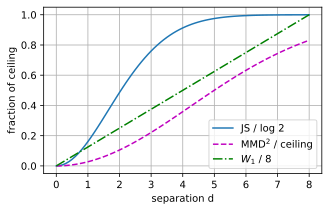

In [2]:
xs = np.linspace(-10.0, 18.0, 5601)           # fixed quadrature grid

def normal_pdf(x, mu, sigma=1.0):
    return np.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / np.sqrt(
        2 * np.pi * sigma ** 2)

def js_1d(p, q):
    m = (p + q) / 2
    return 0.5 * np.trapezoid(p * np.log(p / m) + q * np.log(q / m), xs)

ell = 4.0                                      # RBF kernel length scale
seps = np.linspace(0.0, 8.0, 81)
js = np.array([js_1d(normal_pdf(xs, 0.0), normal_pdf(xs, d)) for d in seps])
w1 = seps                                      # translation: W1 = |d| exactly
ceiling = 2 * ell / np.sqrt(ell ** 2 + 2)
mmd2 = ceiling * (1 - np.exp(-seps ** 2 / (2 * (ell ** 2 + 2))))
print(f'JS at d = 8: {js[-1]:.6f} nats (ceiling log 2 = {np.log(2):.6f})')
d2l.plot(seps, [js / np.log(2), mmd2 / ceiling, w1 / 8],
         xlabel='separation d', ylabel='fraction of ceiling',
         legend=['JS / log 2', 'MMD$^2$ / ceiling', '$W_1$ / 8'],
         figsize=(5, 3))

The three curves follow the behavior predicted by their definitions. Jensen--Shannon increases while the densities overlap and then approaches its ceiling. At a separation of about seven standard deviations, it is within a tenth of a percent of $\log 2$ and has a numerically negligible slope. An objective based on this value therefore provides almost no information about $d$ after the overlap disappears. By contrast, the unscaled $W_1$ equals $d$ and has slope one at every separation; the plot normalizes it by its value at the right edge. MMD retains a visible slope over this sweep, but it approaches its ceiling on the scale set by the kernel length $\ell$. A fixed bounded kernel thus becomes insensitive at sufficiently large separations. A smaller $\ell$ would cause the MMD curve to flatten within the plotted range. The kernel length determines the separations over which MMD provides a useful gradient.

### One Testbed, Four Losses

Every divergence in the table vanishes at $q=p$, but the associated links and gradients differ. We test both properties by training one generator on one target under four objectives: the non-saturating logistic loss of that section, least squares [@Mao.Li.Xie.ea.2017], hinge [@Lim.Ye.2017], and MMD with a fixed kernel and no critic. The supports overlap throughout, which isolates behavior near the shared minimizer from the saturation caused by disjoint supports. We hold the architecture, learning rates, and update counts fixed rather than tuning each objective separately. Differences among the trajectories therefore reflect both the scale of each loss and the information represented by its link.

The target is a two-dimensional mixture of three Gaussians. The generator extends the tractable construction used in that section. It draws one of three components uniformly and applies a learned affine map, $x' = \mu_c + z A_c$. Consequently, $q$ remains a three-component Gaussian mixture whose density can be evaluated in closed form after every training step. This density provides two measurements unavailable from a sample plot alone: the exact $\mathrm{JS}(p,q_t)$ along each trajectory, evaluated by quadrature on a fixed grid, and the exact log ratio $\lambda$ used in the critic diagnostic.

In [3]:
mu_p = np.array([[0.0, 2.4], [-2.1, -1.2], [2.1, -1.2]])
A_p = np.stack([0.7 * np.eye(2)] * 3)

def mixture_logpdf(x, mus, As):
    """Log density of the uniform mixture of Gaussians N(mu_k, A_k^T A_k)."""
    comps = []
    for mu, A in zip(mus, As):
        Sigma, diff = A.T @ A, x - mu
        sol = np.linalg.solve(Sigma, diff.T).T
        comps.append(-0.5 * ((diff * sol).sum(1)
                             + np.log(np.linalg.det(2 * np.pi * Sigma))))
    comps = np.stack(comps) - np.log(len(mus))
    cmax = comps.max(axis=0)
    return cmax + np.log(np.exp(comps - cmax).sum(axis=0))

def sample_mixture(n, mus, As, rng):
    c = rng.integers(0, len(mus), n)
    z = rng.standard_normal((n, 2))
    return np.einsum('ni,nij->nj', z, As[c]) + mus[c]

grid_1d = np.linspace(-7.0, 7.0, 281)
gx, gy = np.meshgrid(grid_1d, grid_1d)
grid_2d = np.stack([gx.ravel(), gy.ravel()], axis=1)
cell_area = (grid_1d[1] - grid_1d[0]) ** 2

def js_mixtures(mus_q, As_q):
    """JS(p, q) between two known mixtures, by quadrature on a fixed grid."""
    logp = mixture_logpdf(grid_2d, mu_p, A_p)
    logq = mixture_logpdf(grid_2d, mus_q, As_q)
    p, q = np.exp(logp), np.exp(logq)
    logm = np.log(np.maximum((p + q) / 2, 1e-300))
    return 0.5 * (p * (logp - logm) + q * (logq - logm)).sum() * cell_area

def farthest_point_init(X, K):
    idx = [0]
    for _ in range(K - 1):
        dist = np.min(np.linalg.norm(X[:, None] - X[idx][None], axis=2),
                      axis=1)
        idx.append(int(np.argmax(dist)))
    return X[idx]

The generator's component means are initialized at three data points chosen by a farthest-point traversal of one batch, a common seeding for mixture fitting; the component maps start well below the data's spread, so shapes, scales, and positions all remain to be learned, and the initial mismatch is over half a nat of JS. The critic is a small leaky-ReLU network, built by a factory so that every run starts identically.

In [4]:
class MixtureGenerator(nn.Module):
    """x = mu_c + z A_c for a uniformly drawn component c."""
    def __init__(self, init_mu):
        super().__init__()
        K = len(init_mu)
        g = torch.Generator().manual_seed(0)
        self.mu = nn.Parameter(torch.tensor(init_mu, dtype=torch.float32))
        self.A = nn.Parameter(0.4 * torch.eye(2).repeat(K, 1, 1)
                              + 0.05 * torch.randn(K, 2, 2, generator=g))

    def forward(self, z, c):
        return torch.einsum('ni,nij->nj', z, self.A[c]) + self.mu[c]

    def params_np(self):
        return (self.mu.detach().numpy().copy(),
                self.A.detach().numpy().copy())

def make_critic():
    torch.manual_seed(1)
    return nn.Sequential(nn.Linear(2, 64), nn.LeakyReLU(0.2),
                         nn.Linear(64, 64), nn.LeakyReLU(0.2),
                         nn.Linear(64, 1))

rng = np.random.default_rng(42)
init_mu = farthest_point_init(sample_mixture(256, mu_p, A_p, rng), 3)
print(f'JS(p, q) at initialization: '
      f'{js_mixtures(*MixtureGenerator(init_mu).params_np()):.3f} nats')

JS(p, q) at initialization: 0.537 nats


The three adversarial objectives use paired critic and generator losses, with a non-saturating generator loss in each case, as in that section. The least-squares generator moves its scores toward the real-label target, while the hinge generator increases the raw critic score. MMD is a single differentiable objective and requires no critic. Summing RBF kernels over three length scales makes this fixed kernel sensitive at several resolutions.

In [5]:
softplus = nn.functional.softplus
critic_losses = {
    'logistic': lambda real, fake: (softplus(-real) + softplus(fake)).mean(),
    'least squares': lambda real, fake: (((real - 1) ** 2).mean()
                                         + (fake ** 2).mean()) / 2,
    'hinge': lambda real, fake: (torch.relu(1 - real)
                                 + torch.relu(1 + fake)).mean(),
}
generator_losses = {
    'logistic': lambda fake: softplus(-fake).mean(),
    'least squares': lambda fake: ((fake - 1) ** 2).mean() / 2,
    'hinge': lambda fake: (-fake).mean(),
}

def mmd2_loss(x, y, ells=(0.5, 1.0, 2.0)):
    """Unbiased MMD^2, summed over three RBF length scales."""
    n, m = len(x), len(y)
    dxx, dyy, dxy = (torch.cdist(x, x) ** 2, torch.cdist(y, y) ** 2,
                     torch.cdist(x, y) ** 2)
    val = 0.0
    for ell in ells:
        kxx, kyy, kxy = [torch.exp(-dist / (2 * ell ** 2))
                         for dist in (dxx, dyy, dxy)]
        val = val + ((kxx.sum() - kxx.diag().sum()) / (n * (n - 1))
                     + (kyy.sum() - kyy.diag().sum()) / (m * (m - 1))
                     - 2 * kxy.mean())
    return val

For the adversarial objectives, the training loop alternates critic and generator updates; for MMD, it applies a single gradient update. Every two hundred steps, the loop records the exact $\mathrm{JS}(p,q_t)$. It also stores the generator at a fixed intermediate step, when the mismatch is still substantially larger than its final residual. Freezing this known, imperfect generator makes it possible to evaluate the critic diagnostic below.

In [6]:
def train_toy(loss_name, steps=6000, batch=256, lr=1e-3, snap_step=1600):
    rng = np.random.default_rng(0)
    torch.manual_seed(0)
    G = MixtureGenerator(init_mu)
    opt_G = torch.optim.Adam(G.parameters(), lr)
    D = make_critic() if loss_name != 'MMD' else None
    opt_D = torch.optim.Adam(D.parameters(), 2 * lr) if D is not None else None
    trace, snapshot = [], None
    for t in range(steps):
        X = torch.tensor(sample_mixture(batch, mu_p, A_p, rng),
                         dtype=torch.float32)
        z = torch.randn(batch, 2)
        c = torch.randint(0, 3, (batch,))
        if loss_name == 'MMD':
            opt_G.zero_grad()
            mmd2_loss(X, G(z, c)).backward()
            opt_G.step()
        else:
            opt_D.zero_grad()
            critic_losses[loss_name](
                D(X).squeeze(), D(G(z, c).detach()).squeeze()).backward()
            opt_D.step()
            opt_G.zero_grad()
            generator_losses[loss_name](D(G(z, c)).squeeze()).backward()
            opt_G.step()
        if t % 200 == 0:
            trace.append(js_mixtures(*G.params_np()))
        if t == snap_step:
            snapshot = G.params_np()       # mismatch still visible here
    return G, np.array(trace), snapshot

runs = {}
for name in ['logistic', 'least squares', 'hinge', 'MMD']:
    runs[name] = train_toy(name)
    print(f'{name:14s} final JS(p, q) = '
          f'{js_mixtures(*runs[name][0].params_np()):.4f} nats')

logistic       final JS(p, q) = 0.0011 nats


least squares  final JS(p, q) = 0.0013 nats


hinge          final JS(p, q) = 0.0059 nats


MMD            final JS(p, q) = 0.0001 nats


Every objective reduces the Jensen--Shannon divergence from more than half a nat at initialization to a few hundredths of a nat. The final errors are not equal: in both frameworks, the hinge residual is consistently several times larger than the residuals of the smooth losses. The panels overlay samples from each trained generator on the data. All four generators assign mass to all three modes and approximate their shapes. Numerical residuals vary by about an order of magnitude across reruns, but the common convergence and the larger hinge residual remain consistent.

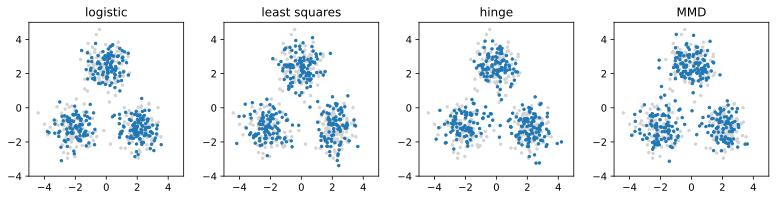

In [7]:
fig, axes = d2l.plt.subplots(1, 4, figsize=(11, 2.9))
rng = np.random.default_rng(5)
X_real = sample_mixture(300, mu_p, A_p, rng)
for ax, name in zip(axes, runs):
    fake = sample_mixture(300, *runs[name][0].params_np(), rng)
    ax.scatter(X_real[:, 0], X_real[:, 1], s=6, c='lightgray')
    ax.scatter(fake[:, 0], fake[:, 1], s=6)
    ax.set_title(name)
    ax.set_xlim(-5, 5), ax.set_ylim(-4, 5)
fig.tight_layout()

Although the objectives approach the same distribution, their optimization trajectories differ. The exact $\mathrm{JS}(p,q_t)$ traces show these differences:

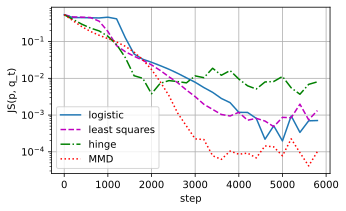

In [8]:
steps_axis = np.arange(len(runs['logistic'][1])) * 200
d2l.plot(steps_axis, [runs[name][1] for name in runs],
         xlabel='step', ylabel='JS(p, q_t)', yscale='log',
         legend=list(runs), figsize=(5, 3))

Two differences persist across reruns and frameworks. MMD, whose minibatch objective requires no learned critic, decreases smoothly and reaches the smallest residual. The logistic and least-squares runs reach similar fits after an initial period of limited progress. The hinge run improves early but remains noisier and converges to a residual several times larger than those of the smooth losses. Its link provides one possible explanation. The optimal hinge critic retains only the sign of $\lambda$, so near the solution it indicates the direction of the mismatch but not its magnitude. Logistic and least-squares critics continue to represent the size of the residual. The experiments are consistent with this interpretation but do not establish a theorem about the optimization dynamics. The individual trajectories vary because stochastic optimization determines which distributions are evaluated along the path. The robust conclusion is that objectives with the same minimizer can produce substantially different training dynamics.

### What Each Critic Estimates

The table's link column made a sharper prediction than convergence: at its pointwise optimum, the logistic critic reports $\lambda$, the least-squares critic reports the posterior $\sigma(\lambda)$, and the hinge critic reports only $\operatorname{sign} \lambda$. The snapshot generator makes the prediction testable, because its $q$ is a known mixture and $\lambda = \log p - \log q$ is available in closed form at every point. The theorem concerns the best response to a *fixed* generator, so, as in that section, we freeze the snapshot and train a fresh critic under each loss to convergence, then compare critic outputs with the predicted transform of the analytic $\lambda$ at samples from the mixture.

snapshot JS(p, q) = 0.046 nats


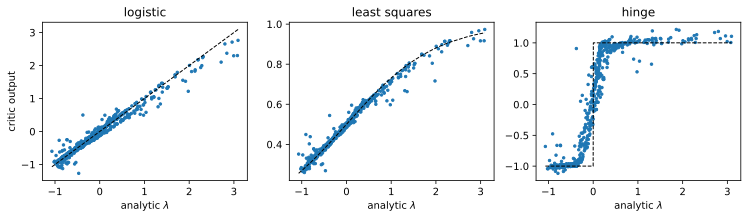

In [9]:
mus_s, As_s = runs['logistic'][2]              # the frozen snapshot
print(f'snapshot JS(p, q) = {js_mixtures(mus_s, As_s):.3f} nats')

def best_response(loss_name, steps=3000, batch=512, lr=1e-3):
    rng = np.random.default_rng(11)
    torch.manual_seed(11)
    D = make_critic()
    opt = torch.optim.Adam(D.parameters(), lr)
    for _ in range(steps):
        X = torch.tensor(sample_mixture(batch, mu_p, A_p, rng),
                         dtype=torch.float32)
        Y = torch.tensor(sample_mixture(batch, mus_s, As_s, rng),
                         dtype=torch.float32)
        opt.zero_grad()
        critic_losses[loss_name](D(X).squeeze(), D(Y).squeeze()).backward()
        opt.step()
    return D

rng = np.random.default_rng(7)
pts = np.concatenate([sample_mixture(300, mu_p, A_p, rng),
                      sample_mixture(300, mus_s, As_s, rng)])
lam = mixture_logpdf(pts, mu_p, A_p) - mixture_logpdf(pts, mus_s, As_s)
order = np.argsort(lam)
links = {'logistic': lambda l: l,
         'least squares': lambda l: 1 / (1 + np.exp(-l)),
         'hinge': lambda l: np.sign(l)}
fig, axes = d2l.plt.subplots(1, 3, figsize=(10.5, 3.2))
for ax, name in zip(axes, links):
    D = best_response(name)
    with torch.no_grad():
        out = D(torch.tensor(pts, dtype=torch.float32)).squeeze().numpy()
    ax.scatter(lam, out, s=6)
    ax.plot(lam[order], links[name](lam[order]), 'k--', lw=1)
    ax.set_title(name), ax.set_xlabel(r'analytic $\lambda$')
axes[0].set_ylabel('critic output')
fig.tight_layout()

The three critics recover different transforms of the same underlying function. The logistic critic follows the identity line, the least-squares critic follows the sigmoid, and the hinge critic approximates a step at $\lambda=0$. All three estimates become less accurate where $|\lambda|$ is large because the mixture supplies few samples in those regions. As in that section, the objective constrains a critic primarily on the support of the mixture.

The hinge critic has an additional source of indeterminacy. Where one class dominates, the hinge risk is constant once the score crosses the margin, so values beyond $\pm 1$ incur no additional cost. The scatter outside the two plateaus reflects this nonuniqueness. A hinge critic estimates the *set* on which $p$ exceeds $q$, not the magnitude of the ratio there. Whether this coarser information suffices depends on the generator update.

### Recovering the Ratio by Duality

The preceding diagnostic verified the link induced by a classification loss. Equation the equation makes a corresponding prediction for the dual construction and for a divergence that no bounded loss can produce. For forward KL, the optimal critic is $T^\star = 1+\lambda$, and the optimal objective equals $\mathrm{KL}(p\,\|\,q)$. Both quantities are available in closed form for $p=\mathcal{N}(0,1)$ and $q=\mathcal{N}(2,1.5^2)$. Their log density ratio is quadratic, and their divergence follows from the Gaussian KL formula used in that section. We train a small network with the objective $E_p[T]-E_q[e^{T-1}]$. No output activation is required because the KL conjugate is finite on all of $\mathbb{R}$.

In [10]:
mu0, s0, mu1, s1 = 0.0, 1.0, 2.0, 1.5
torch.manual_seed(3)
rng = np.random.default_rng(3)
net_T = nn.Sequential(nn.Linear(1, 64), nn.Tanh(),
                      nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
opt = torch.optim.Adam(net_T.parameters(), lr=1e-3)
for t in range(4000):
    xp = torch.tensor(rng.normal(mu0, s0, (512, 1)), dtype=torch.float32)
    xq = torch.tensor(rng.normal(mu1, s1, (512, 1)), dtype=torch.float32)
    opt.zero_grad()
    loss = -(net_T(xp).mean() - torch.exp(net_T(xq) - 1).mean())
    loss.backward()
    opt.step()

kl_exact = np.log(s1 / s0) + (s0 ** 2 + (mu0 - mu1) ** 2) / (2 * s1 ** 2) - 0.5
xp = torch.tensor(rng.normal(mu0, s0, (100000, 1)), dtype=torch.float32)
xq = torch.tensor(rng.normal(mu1, s1, (100000, 1)), dtype=torch.float32)
with torch.no_grad():
    bound = (net_T(xp).mean() - torch.exp(net_T(xq) - 1).mean()).item()
print(f'exact KL(p || q) = {kl_exact:.4f}, attained bound = {bound:.4f}')

exact KL(p || q) = 1.0166, attained bound = 1.0138


The attained bound is within about one percent of the exact divergence and, as required, remains below it. An imperfect critic can only underestimate an f-divergence, so a finite adversarial estimate has downward bias; that section states this result in general. Comparing the trained critic with the analytic optimum localizes the remaining error:

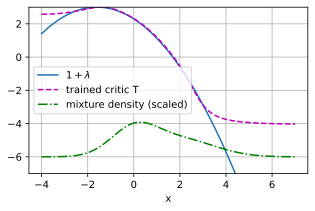

In [11]:
def normal_logpdf(x, mu, s):
    return -0.5 * ((x - mu) / s) ** 2 - np.log(s * np.sqrt(2 * np.pi))

xs_f = np.linspace(-4.0, 7.0, 401)
lam_f = normal_logpdf(xs_f, mu0, s0) - normal_logpdf(xs_f, mu1, s1)
with torch.no_grad():
    T_vals = net_T(torch.tensor(xs_f[:, None],
                                dtype=torch.float32)).squeeze().numpy()
mix = 0.5 * np.exp(normal_logpdf(xs_f, mu0, s0)) \
    + 0.5 * np.exp(normal_logpdf(xs_f, mu1, s1))
d2l.plot(xs_f, [1 + lam_f, T_vals, 8 * mix - 6], xlabel='x',
         legend=[r'$1 + \lambda$', 'trained critic T',
                 'mixture density (scaled)'],
         ylim=(-7, 3), figsize=(5, 3))

Where the mixture density is appreciable, the trained critic follows the analytic parabola $1+\lambda$. In the tails, samples are rare, the estimate flattens, and the analytic parabola continues to change. The critic estimates the density ratio accurately only where the training distribution provides enough data to constrain it.

### Estimation from Samples

Gradient behavior is only one criterion for choosing an objective; statistical estimation can reverse the ordering. The unbiased MMD estimator converges at the parametric rate $O(n^{-1/2})$ regardless of dimension [@Gretton.Borgwardt.Rasch.ea.2012], while @Sriperumbudur.Fukumizu.Gretton.ea.2012 analyze IPM estimators more broadly. Estimating $W_1$ from samples suffers from the curse of dimensionality. In dimension $d>2$, the empirical measure converges in Wasserstein distance at rate $n^{-1/d}$ [@Weed.Bach.2019]. Halving the error can therefore require $2^d$ times as many samples.

Density-ratio estimation, required by the f-divergence family, is hardest where the ratio is extreme. The plug-in KL objective above involves second moments of $e^T$ under $q$. At the optimum these are moments of the density ratio, and they can be infinite even when the divergence is finite. Thus the ratio estimate is least reliable in precisely the regions where $p$ and $q$ differ most, as the flattened tails of the previous figure showed.

No choice dominates on every criterion. MMD has the cheapest estimator but supplies a discrepancy whose behavior depends on its kernel. Wasserstein distance preserves geometry across separated supports but is expensive to estimate in high dimensions. Density-ratio objectives can define strong discrepancies but become statistically difficult when the distributions differ sharply.

## Summary

The template the equation takes a supremum, over a critic class, of a difference between expected critic scores. It is jointly convex in $(p,q)$ because it is a supremum of affine functionals. With an unrestricted critic, changing the classification loss produces different f-divergences. The concave Bayes risk of each loss defines the gap the equation, and the proposition identifies that gap with $D_f$. Logistic, least-squares, and hinge losses yield Jensen--Shannon divergence, triangular discrimination, and total variation, respectively.

Fenchel duality extends the construction beyond this loss table. Any convex generator $f$ gives the trainable bound the equation, which is attained at $T^\star=f'(\rho)$. An unrestricted critic therefore estimates a transform of the density ratio, with the objective determining the transform. The Jensen--Shannon choice reproduces the original GAN value function of that section. Alternatively, restricting a critic with linear scores gives the integral probability metrics the equation. A reproducing-kernel Hilbert space ball yields MMD, whose supremum is analytic for a fixed kernel. A Lipschitz ball yields $W_1$ through Kantorovich--Rubinstein duality and requires an approximate constraint when implemented by a neural critic.

The two families differ when supports separate. A density-ratio objective then becomes insensitive to the distance between the supports: in the experiment, Jensen--Shannon approaches its $\log 2$ ceiling. By contrast, $W_1$ retains unit slope, and MMD retains a gradient over distances determined by its kernel length. These geometry-sensitive objectives can be weaker discrepancies or more expensive to estimate. MMD has a dimension-independent parametric estimation rate, while empirical Wasserstein distance converges slowly in high dimensions.

When the supports overlap, all four tested objectives move the generator toward the same distribution, although their optimization paths and residual errors differ. Their critics estimate different transforms of the same log ratio $\lambda$. that section collects these correspondences between objectives and discrepancies. No choice simultaneously provides strong gradients under separation and uniformly easy estimation. The next section retains the log loss but changes the critic from scoring individual samples to scoring pairs.

## Exercises

1. Derive the Bayes-risk gap of the Brier loss. The Brier score predicts a probability $s \in (0, 1)$ and pays $(y - s)^2$ against the label $y \in \{0, 1\}$. Show that its conditional Bayes risk is $L(\eta) = \eta(1 - \eta)$, then evaluate the equation and confirm the table's square row, $\Delta_\ell = \tfrac18 \int (p - q)^2/(p + q)$.
1. The zero--one loss pays $1$ for a wrong sign and $0$ for a right one, so $L(\eta) = \min(\eta, 1 - \eta)$. Show from the equation that $\Delta_{0\textrm{--}1} = \tfrac12 \mathrm{TV}(p, q)$ with $\mathrm{TV} = \tfrac12 \int |p - q|$, using $\min(a, b) = \tfrac12(a + b - |a - b|)$. The hinge row's value is exactly twice this. Explain the factor of two from the Bayes risks alone, and why the two rows share the same optimal critic.
1. Verify numerically that LSGAN's divergence is the triangular discrimination. On random pairs of discrete distributions (for example, normalized draws from a Dirichlet on five outcomes), compute the square row's gap $\Delta = \tfrac14 - \sum_x m(x)\, \eta(x)(1 - \eta(x))$ with $\eta = p/(p+q)$ and $m = (p+q)/2$, and the triangular discrimination $\triangle(p, q) = \sum_x (p(x) - q(x))^2 / (p(x) + q(x))$. Confirm that $\triangle = 8\,\Delta$ to machine precision on every draw.
1. In the separation experiment, replace the RBF kernel with the linear kernel $k(x, y) = xy$, for which $\mathrm{MMD}^2(p, q) = (E_p[x] - E_q[x])^2$. For the translated pair the curve becomes $d^2$ and looks healthy. Now change the experiment so that the two distributions differ in scale instead of location, $p = \mathcal{N}(0, 1)$ and $q = \mathcal{N}(0, (1 + d)^2)$: which of the three objectives still detects the difference, and what does the linear-kernel MMD report? Relate the failure to the notion of a characteristic kernel, for which the mean embedding determines the distribution.
1. From the variational bound the equation with the generator $f(u) = u \log u - (u + 1) \log \frac{u+1}{2}$, derive the conjugate $f^*(t) = -\log(2 - e^t)$ and its domain $t < \log 2$, determine the output activation that a network implementing $T$ needs, and show that the reparameterization $T = \log(2\sigma(D))$ turns the bound's objective into $2 \log 2$ plus the value function of the original GAN, recovering the analysis of that section.

[Discussions](https://d2l.discourse.group/)